In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv('boston_housing.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
X = df[['RM']]
y = df[['MEDV']]

In [7]:
X.size

506

In [8]:
y.size

506

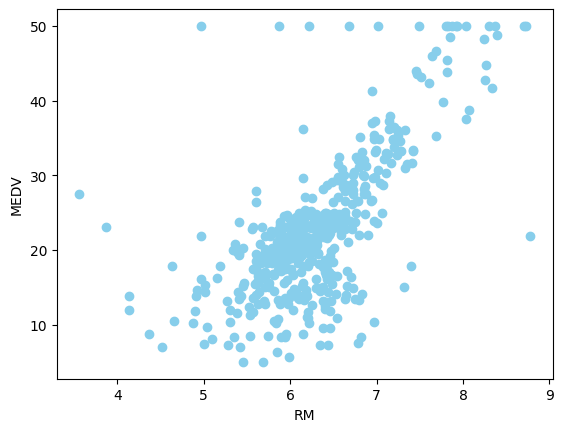

In [9]:
plt.scatter(df['RM'], df['MEDV'], color = 'skyblue', marker = 'o')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.33,
    random_state = 42,
)

In [11]:
model = LinearRegression()

In [12]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))
print("R2 Score: ", r2_score(y_test, y_pred))

Mean Squared Error:  39.09105111486995
R2 Score:  0.4834590168919489


In [15]:
print(model.intercept_)
print(model.coef_)

[-34.22235235]
[[9.03907314]]


# Multiple Linear Regression

### Using the Same Dataset. But this time we use more columns, such as RM, INDUS, DIS, TAX. 

In [16]:
df.shape

(506, 14)

In [17]:
X = df[['RM', 'INDUS', 'DIS', 'TAX']]
y = df['MEDV']

In [18]:
print(X.shape)
print(y.shape)

(506, 4)
(506,)


#### To know the Multicollinearity, we use VIF.

In [19]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [20]:
import statsmodels
print(statsmodels.__version__)

0.15.0


In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.Series([ 
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
], index = X.columns)
print(vif)

RM       1.196445
INDUS    3.258492
DIS      2.035552
TAX      2.087118
dtype: float64


In [28]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [29]:
import seaborn as sns

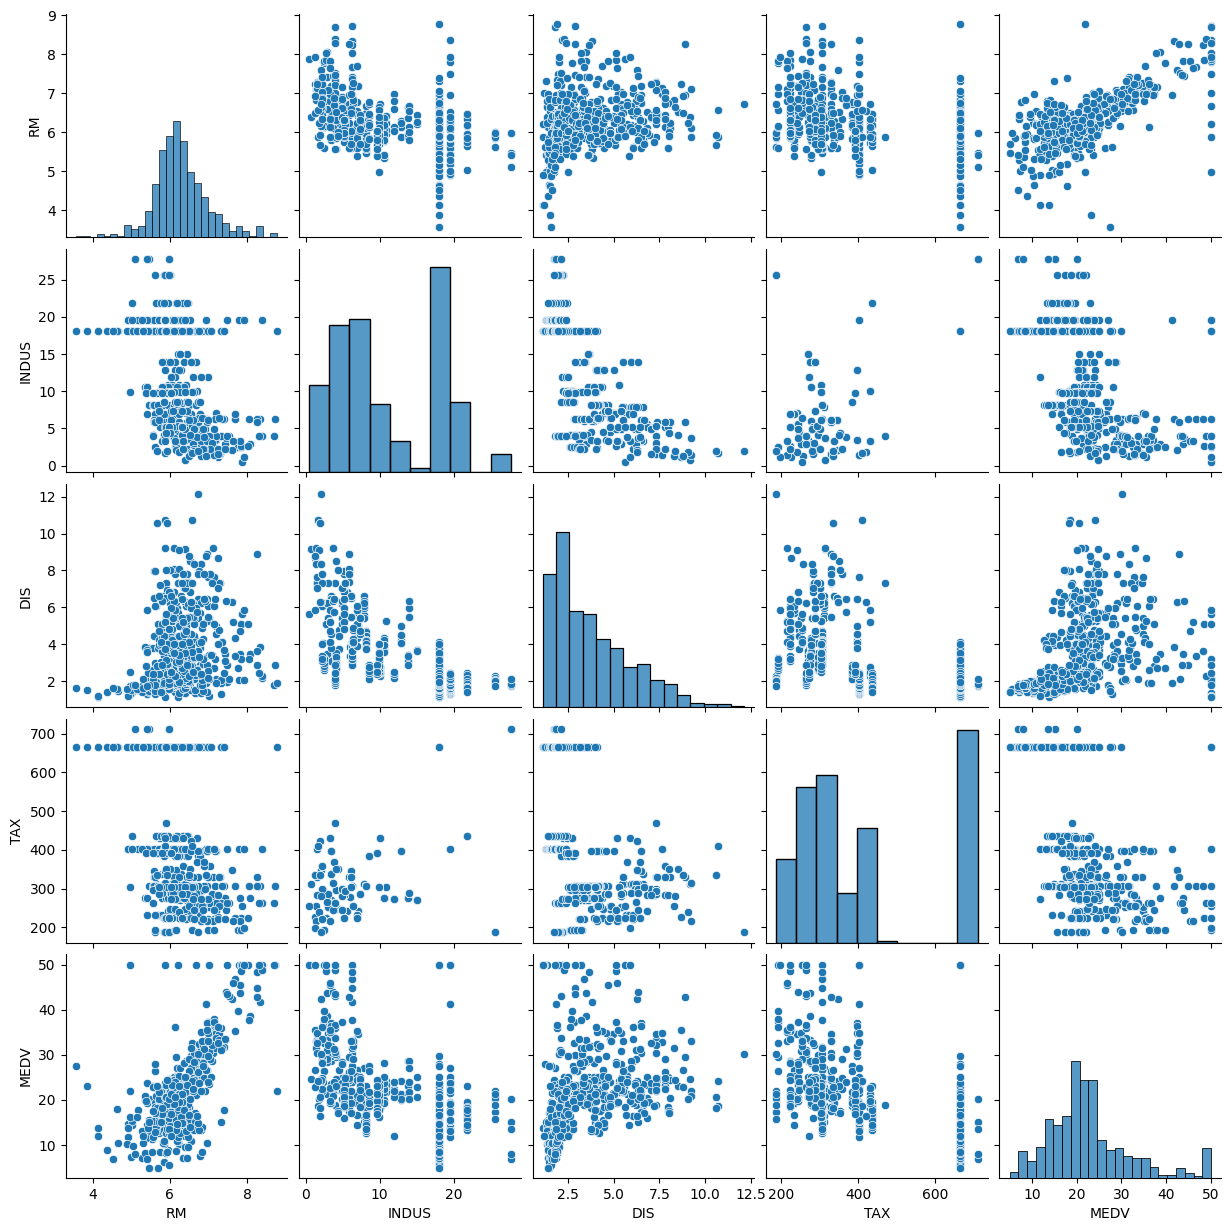

In [35]:
data = df[['RM', 'INDUS', 'DIS', 'TAX', 'MEDV']]
sns.pairplot(data)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.33,
    random_state = 42
)

In [39]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
print("Intercept: ", model.intercept_ , "\nCoefficient: ", model.coef_)

Intercept:  -17.588219333499566 
Coefficient:  [ 7.79091585 -0.13518043 -0.39254682 -0.0140231 ]


In [43]:
y_pred = model.predict(X_test)

In [44]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

In [45]:
print("Train Score (R2): ", train_score)
print("Test Score (R2): ", test_score)

Train Score (R2):  0.5489623704602898
Test Score (R2):  0.6070866072150631
